# 02 — Exploração do Pipeline de Pré-processamento

Este notebook tem dois objetivos:
1. **Visualizar** cada etapa do pipeline em imagens individuais
2. **Comparar** variantes de configuração usando SSIM e PSNR

Todas as configurações são lidas do `config.yaml` na raiz do projeto.
Para mudar parâmetros, edite o YAML — não este notebook.

In [1]:
import sys
sys.path.insert(0, '..')  # permite importar src/ a partir da pasta notebooks/

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import load_image, show_comparison
from src.preprocessing import Pipeline, shades_of_gray, sharp_razor, apply_clahe
from src.evaluation import calculate_ssim_psnr, evaluate_pipeline_variants
from src.segmentation.segmentation import Segmentation

with open('../../config.yaml') as f:
    cfg = yaml.safe_load(f)

pipeline = Pipeline(cfg)
segment = Segmentation(cfg)
print('Pipeline carregado. Config de pré-processamento:')
print('Segmentation carregado. Config de segmentação:')
print(yaml.dump(cfg['preprocessing'], allow_unicode=True))
print(yaml.dump(cfg['segmentation'], allow_unicode=True))

Pipeline carregado. Config de pré-processamento:
Segmentation carregado. Config de segmentação:
clahe:
  clip_limit: 0.5
  tile_grid_size:
  - 8
  - 8
color_constancy:
  method: shades_of_gray
  p: 6
hair_removal:
  inpaint_radius: 3
  max_solidity: 0.9
  method: sharp_razor
  min_area: 10
normalize:
  enabled: false
  scale: 255.0
resize:
  height: 256
  image_interpolation: bilinear
  mask_interpolation: nearest_neighbor
  width: 256

traditional_method:
- otsu
- watershed
- grabcut



## 1. Carregar imagem de teste

Shape: (767, 1022, 3) | dtype: uint8


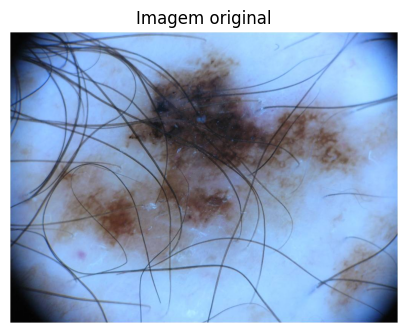

In [2]:
# Altere o caminho para qualquer imagem do ISIC 2018
IMAGE_PATH = '../data/raw/training/input/ISIC_0000074.jpg'

img_original = load_image(IMAGE_PATH)
print(f'Shape: {img_original.shape} | dtype: {img_original.dtype}')

plt.figure(figsize=(5, 5))
plt.imshow(img_original[:, :, ::-1])  # BGR -> RGB
plt.title('Imagem original')
plt.axis('off')
plt.show()

## 2. Visualizar cada etapa do pipeline

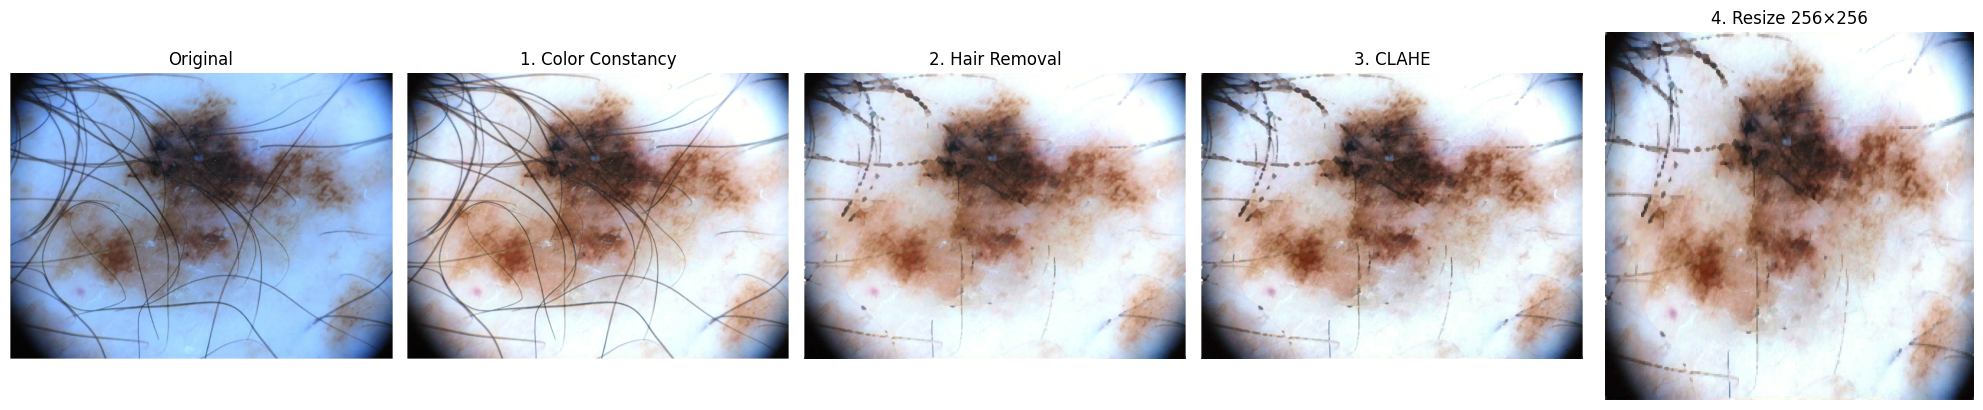

In [3]:
img_cc   = pipeline.step_color_constancy(img_original)
img_hr   = pipeline.step_hair_removal(img_cc)
img_cl   = pipeline.step_clahe(img_hr)
img_rs   = pipeline.step_resize(img_cl)

show_comparison({
    'Original':         img_original,
    '1. Color Constancy': img_cc,
    '2. Hair Removal':  img_hr,
    '3. CLAHE':         img_cl,
    '4. Resize 256×256': img_rs,
}, figsize=(20, 4))

## 3. Compara os algoritmos de Color Constancy

Calcula SSIM/PSNR em relação à imagem original.

## 4. Compara os algoritmos disponíveis para Hair Removal

Calcula SSIM/PSNR em relação à imagem original.

## 5. Busca pelo melhor clip_limit do CLAHE

Itera sobre uma faixa de valores e calcula SSIM/PSNR em relação à imagem original.

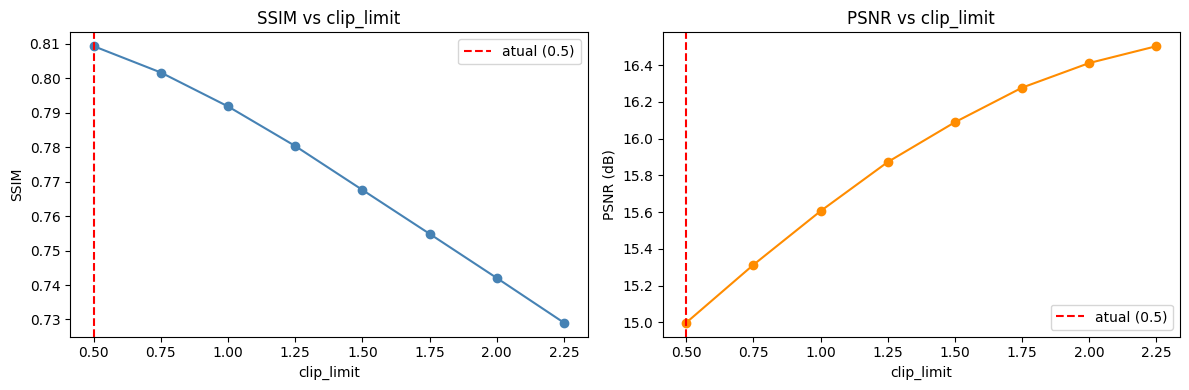


Resultados:


,clip_limit,ssim,psnr
0,0.50,0.809341,14.998281
1,0.75,0.801693,15.313217
2,1.00,0.791844,15.605619
3,1.25,0.780355,15.872538
4,1.50,0.767607,16.089143
5,1.75,0.754861,16.277265
6,2.00,0.742034,16.411191
7,2.25,0.729049,16.502772


In [4]:
exp_cfg = cfg['experiments']['clip_limit_search']
clip_limits = np.arange(exp_cfg['start'], exp_cfg['stop'], exp_cfg['step'])

rows = []
for clip in clip_limits:
    processed = apply_clahe(img_hr, clip_limit=float(clip))
    m = calculate_ssim_psnr(img_original, processed)
    rows.append({'clip_limit': round(float(clip), 2), **m})

df_clip = pd.DataFrame(rows)
df_clip.to_csv('../results/metrics/clip_limit_search.csv', index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(df_clip['clip_limit'], df_clip['ssim'], marker='o', color='steelblue')
ax1.set(xlabel='clip_limit', ylabel='SSIM', title='SSIM vs clip_limit')
ax1.axvline(x=cfg['preprocessing']['clahe']['clip_limit'], color='red',
            linestyle='--', label=f"atual ({cfg['preprocessing']['clahe']['clip_limit']})")
ax1.legend()

ax2.plot(df_clip['clip_limit'], df_clip['psnr'], marker='o', color='darkorange')
ax2.set(xlabel='clip_limit', ylabel='PSNR (dB)', title='PSNR vs clip_limit')
ax2.axvline(x=cfg['preprocessing']['clahe']['clip_limit'], color='red',
            linestyle='--', label=f"atual ({cfg['preprocessing']['clahe']['clip_limit']})")
ax2.legend()

plt.tight_layout()
plt.savefig('../results/figures/clip_limit_search.png', dpi=150)
plt.show()

print('\nResultados:')
display(df_clip)

## 6. Comparação entre variantes da ordem do pipeline

Comparação entre variantes:


,name,ssim,psnr
0,cc → hr → clahe,0.809341,14.998281
1,cc → clahe → hr,0.806864,14.823409
2,cc → hr (sem clahe),0.820369,14.470895


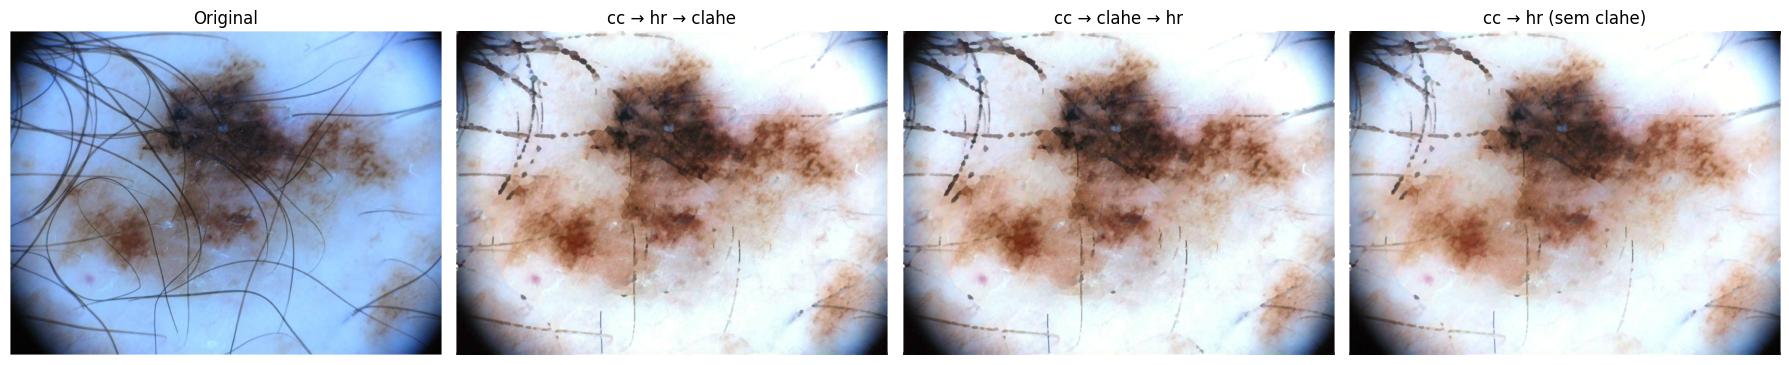

In [5]:
img_cc = pipeline.step_color_constancy(img_original)
img_hr = pipeline.step_hair_removal(img_cc)
img_cl_only = pipeline.step_clahe(img_cc)

variants = {
    'cc → hr → clahe': pipeline.step_clahe(img_hr),
    'cc → clahe → hr': pipeline.step_hair_removal(img_cl_only),
    'cc → hr (sem clahe)': img_hr,
}

results = evaluate_pipeline_variants(img_original, variants)
df_variants = pd.DataFrame(results)
df_variants.to_csv('../results/metrics/pipeline_variants.csv', index=False)

print('Comparação entre variantes:')
display(df_variants)

show_comparison({'Original': img_original, **variants}, figsize=(18, 4))

## 7. Segmentação por Limiarização de Otsu, Watershed e GrabCut


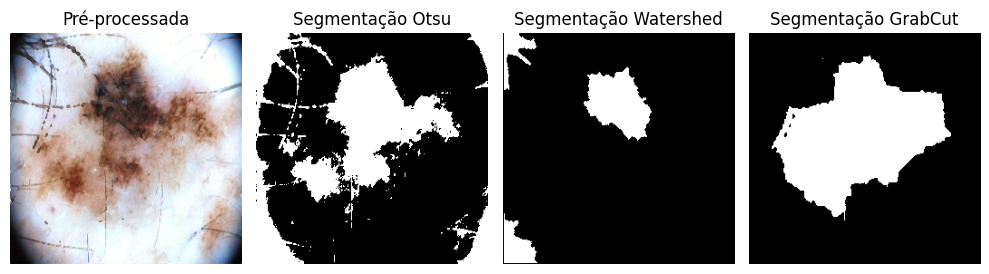

In [8]:
img_cc = pipeline.step_color_constancy(img_original)
img_hr = pipeline.step_hair_removal(img_cc)
img_clahe = pipeline.step_clahe(img_hr)
img_preprocessed = pipeline.step_resize(img_clahe)

# Segmentação tradicional usando a imagem pré-processada
mask_pred_otsu = segment.step_segment_traditional_otsu(img_preprocessed)
mask_pred_watershed = segment.step_segment_traditional_watershed(img_preprocessed)
mask_pred_grabcut = segment.step_segment_traditional_grabcut(img_preprocessed)


show_comparison({
    'Pré-processada': img_preprocessed,
    'Segmentação Otsu': mask_pred_otsu * 255,  # para visualização
    'Segmentação Watershed': mask_pred_watershed * 255,  # para visualização
    'Segmentação GrabCut': mask_pred_grabcut * 255,  # para visualização
}, figsize=(10, 5))